In [20]:
import sys; sys.path.append("../src")
import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt
from quiet_index import data, baskets, risk, optimize, backtest, plots
plots.use_style()

In [41]:

holdings = pandas.read_csv("https://www.ishares.com/us/products/239723/ishares-s-p-100-etf/latest-holdings.csv", skiprows=9)  
equity_holdings = holdings[holdings["Asset Class"] == "Equity"].copy()
print(equity_holdings.head())

  Ticker              Name                  Sector Asset Class  \
0   NVDA            NVIDIA  Information Technology      Equity   
1   AAPL             APPLE  Information Technology      Equity   
2   MSFT         MICROSOFT  Information Technology      Equity   
3   AMZN    AMAZON.COM INC  Consumer Discretionary      Equity   
4  GOOGL  ALPHABET CLASS A           Communication      Equity   

       Market Value  Weight (%)    Notional Value       Quantity   Price  \
0  2,290,304,081.19       11.31  2,290,304,081.19  10,239,657.00  223.67   
1  1,958,051,068.22        9.67  1,958,051,068.22   6,209,333.00  315.34   
2  1,544,026,825.00        7.63  1,544,026,825.00   3,140,500.00  491.65   
3  1,044,550,332.80        5.16  1,044,550,332.80   4,138,472.00  252.40   
4    819,672,091.80        4.05    819,672,091.80   2,478,972.00  330.65   

        Location Exchange Currency  FX Rate Market Currency Accrual Date  
0  United States   NASDAQ      USD      1.0             USD            

In [58]:
equity_holdings["Ticker"].replace({"BRK B":"BRK-B"})
equity_holdings["Ticker"] = equity_holdings["Ticker"].replace({"BRK B": "BRK-B"})
equity_holdings[equity_holdings["Ticker"] == "BRK-B"]

,Ticker,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Quantity,Price,Location,Exchange,Currency,FX Rate,Market Currency,Accrual Date
11,BRK-B,BERKSHIRE HATHAWAY INC CLASS B,Financials,Equity,"392,744,990.56",1.94,"392,744,990.56","775,073.00",506.72,United States,NYSE,USD,1.0,USD,-


In [59]:
members = pandas.DataFrame({
    "ticker":        equity_holdings["Ticker"],
    "snapshot_date": "2026-08-31",
    "source":        "https://www.ishares.com/us/products/239723/ishares-s-p-100-etf/latest-holdings.csv",
})



In [60]:
members.to_csv("../data/reference/sp100_members.csv", index=False)

In [112]:
tickers = pandas.read_csv("../data/reference/sp100_members.csv")["ticker"].tolist()

import yfinance as yfinance 

tickers_data = yfinance.download(tickers, start="2018-01-01", auto_adjust=True, group_by="column", threads=True)["Close"]
benchmark_data = yfinance.download(["SMH", "VXUS", "TLT", "GLD", "MAGS"], start="2018-01-01", auto_adjust=True, group_by="column", threads=True)["Close"]
spy_data = yfinance.download(["SPY"], start="2013-01-01", auto_adjust=True, group_by="column", threads=True)["Close"]

tickers_data.head()

[*********************100%***********************]  101 of 101 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMAT,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.232376,68.287094,50.148415,133.947601,177.699997,48.262596,10.98,135.948105,112.758102,59.450500,...,NaN,191.993896,112.165848,86.965218,38.685276,107.688179,33.147877,48.100590,28.731453,57.811157
2018-01-03,40.225372,69.355690,50.259293,134.565826,181.039993,49.117928,11.55,138.513428,113.197525,60.209999,...,NaN,194.007935,112.793686,88.891991,39.064754,108.760269,32.466717,48.470654,28.982075,58.946571
2018-01-04,40.412220,68.960190,50.173992,136.159195,183.220001,49.399994,12.12,137.929672,111.543678,60.479500,...,NaN,194.850006,112.182343,89.468597,39.365471,109.164658,32.571991,49.076931,29.008307,59.028156
2018-01-05,40.872318,70.160629,50.319008,137.282379,185.339996,49.682060,11.88,138.751526,112.262741,61.457001,...,NaN,198.565613,113.611504,89.742859,39.608906,111.779030,32.497677,49.407635,29.180244,58.980572
2018-01-08,40.720505,69.036499,50.173992,138.379425,185.039993,50.883183,12.28,138.713104,113.461220,62.343498,...,NaN,195.119186,115.189323,90.832825,39.666191,112.230446,32.441940,48.848595,29.611557,59.245724


In [146]:
members_returns = np.log(tickers_data / tickers_data.shift(1))
benchmark_returns = np.log(benchmark_data / benchmark_data.shift(1)).squeeze()
spy_returns = np.log(spy_data / spy_data.shift(1)).squeeze()
      

In [147]:
quarter_ends = members_returns.index.to_series().groupby(members_returns.index.to_period("Q")).max() #create quarter-ends in a series , this is a list of dates in the index that represent quarter ends


In [149]:
def ols_regression(y: pandas.Series, x: pandas.Series, min_obs: int = 200):
    """OLS of y on x. Returns dict or None if too few joint observations."""

    df = pandas.concat({"y": y, "x": x}, axis=1).dropna()
    if len(df) < min_obs:
        return None
    yv, xv = df["y"], df["x"]

    beta  = yv.cov(xv) / xv.var()
    alpha = yv.mean() - beta * xv.mean()
    resid = yv - alpha - beta * xv
    r2    = beta**2 * xv.var() / yv.var()

    return {"alpha": alpha, "beta": beta, "resid": resid, "n": len(df), "r2": r2}

In [118]:
fit = ols_regression(returns["NVDA"].tail(252), spy_returns.tail(252))
print(fit["beta"])

1.9150321967561361


In [150]:
loadings_by_qe = {}
for qe in quarter_ends:
    pos = members_returns.index.get_loc(qe)
    if pos < 251:
        continue                                          # burn-in: skips the 2018 quarter-ends

    members_window = members_returns.iloc[pos-251 : pos+1]
    spy_window     = spy_returns.reindex(members_window.index)
    e_smh          = ols_regression(
                        benchmark_returns["SMH"].reindex(members_window.index),
                        spy_window)["resid"]

    rows = {}
    for ticker in members_window.columns:
        if ticker in MAG7:
            continue
        fit1 = ols_regression(members_window[ticker], spy_window)
        if fit1 is None: continue
        fit2 = ols_regression(fit1["resid"], e_smh)
        if fit2 is None: continue
        rows[ticker] = {"beta_mkt": fit1["beta"], "ai_beta": fit2["beta"], "n_obs": fit1["n"]}

    loadings_by_qe[qe] = pandas.DataFrame.from_dict(rows, orient="index")

print(f"{len(loadings_by_qe)} formations,",
      f"first {min(loadings_by_qe).date()}, last {max(loadings_by_qe).date()}")


/var/folders/55/nnjtr0k13kb9t31swqzssvw80000gn/T/ipykernel_86397/1965547667.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pandas.concat({"y": y, "x": x}, axis=1).dropna()


31 formations, first 2019-03-29, last 2026-09-11


In [143]:
loadings.sort_values("ai_beta", ascending=False).head(10) #stocks with the most beta to SMH/AI (λ)

,beta_mkt,ai_beta,n_obs,momentum
MU,3.322340,1.994775,252,5.519662
INTC,2.804135,1.743681,252,3.075494
LRCX,3.237812,1.538622,252,2.054349
AMAT,2.725920,1.489539,252,2.369191
AMD,3.078967,1.447184,252,2.027015
GEV,2.014507,0.713114,252,0.619525
TXN,1.471406,0.681850,252,0.542051
AVGO,2.119205,0.678188,252,0.134016
CAT,1.739237,0.643270,252,1.041337
QCOM,2.051298,0.547768,252,0.041616


In [126]:
loadings.sort_values("beta_mkt", ascending=False).head(10) #stocks with the most beta to SPY/market (β)

,beta_mkt,ai_beta,n_obs
MU,3.322340,1.994775,252
LRCX,3.237812,1.538622,252
AMD,3.078967,1.447184,252
INTC,2.804135,1.743681,252
AMAT,2.725920,1.489539,252
AVGO,2.119205,0.678188,252
QCOM,2.051298,0.547768,252
ORCL,2.021289,0.152547,252
GEV,2.014507,0.713114,252
PLTR,1.937335,-0.362893,252


In [151]:
momentum = (tickers_data.iloc[pos-21] / tickers_data.iloc[pos-252] - 1).drop(MAG7, errors="ignore") #momentum is defined as the stocks 12 month return (t-21 price / t-252 price) 
loadings["momentum"] = momentum #add momentum column for each stock to the loadings table
loadings.sort_values("momentum", ascending=False).head(10) #stocks with the most momentum

,beta_mkt,ai_beta,n_obs,momentum
MU,3.322340,1.994775,252,5.519662
INTC,2.804135,1.743681,252,3.075494
AMAT,2.725920,1.489539,252,2.369191
LRCX,3.237812,1.538622,252,2.054349
AMD,3.078967,1.447184,252,2.027015
CAT,1.739237,0.643270,252,1.041337
CSCO,1.021517,0.201546,252,0.855939
FDX,0.905122,-0.088094,252,0.820147
MRK,0.187835,-0.243492,252,0.634699
LLY,0.309857,-0.326356,252,0.624949


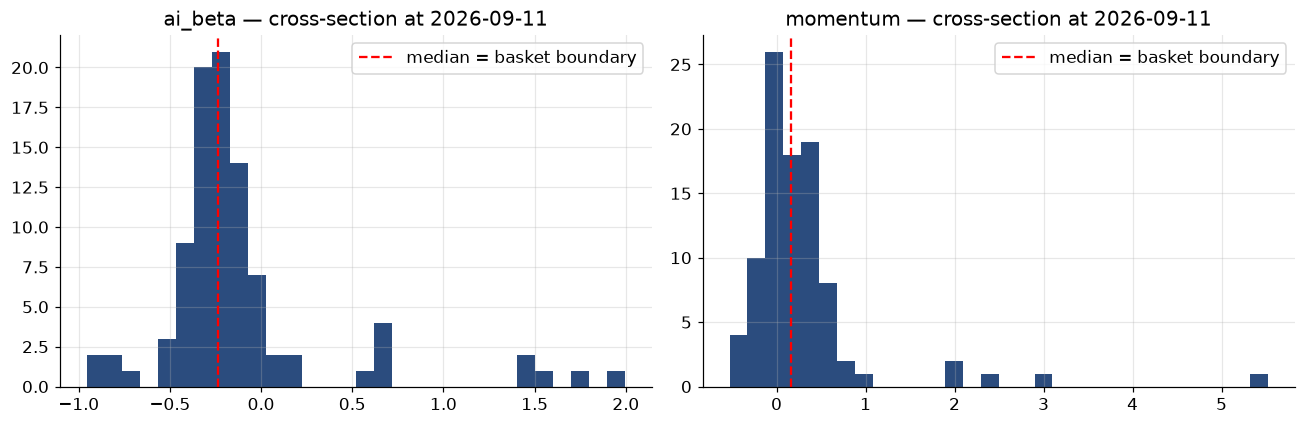

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["ai_beta", "momentum"]):
    loadings[col].hist(bins=30, ax=ax)
    ax.axvline(loadings[col].median(), color="red", ls="--", label="median = basket boundary")
    ax.set_title(f"{col} — cross-section at {qe.date()}")
    ax.legend()
plt.tight_layout()

In [171]:
loadings[["beta_mkt", "ai_beta", "momentum"]].corr(method="spearman")

,beta_mkt,ai_beta,momentum
beta_mkt,1.000000,0.399839,0.280535
ai_beta,0.399839,1.000000,0.707275
momentum,0.280535,0.707275,1.000000


In [172]:
loadings_table = loadings.dropna(subset=["ai_beta", "momentum"]).copy()   # a NaN would silently land in "LO" — evict instead
loadings_table.index.name = "ticker"

hi_ai  = loadings_table["ai_beta"]  >= loadings_table["ai_beta"].median()
hi_mom = loadings_table["momentum"] >= loadings_table["momentum"].median()

pandas.crosstab(hi_ai.map({True: "AI hi", False: "AI lo"}),
                hi_mom.map({True: "Mom hi", False: "Mom lo"}))

momentum,Mom hi,Mom lo
ai_beta,,
AI hi,35,12
AI lo,12,34


In [173]:
basket = np.select([hi_ai & hi_mom, hi_ai & ~hi_mom, ~hi_ai & hi_mom],
                   ["RUSH", "LEFT_BEHIND", "QUIET_WINNERS"], default="RESIDUAL")
loadings_table["basket"] = basket

print(lo[lo["basket"] == "LEFT_BEHIND"].index.tolist())     # high AI-beta, weak year
print(lo[lo["basket"] == "QUIET_WINNERS"].index.tolist())   # strong year, low AI-beta

['AVGO', 'BA', 'BLK', 'BRK-B', 'COST', 'DUK', 'LIN', 'ORCL', 'PFE', 'QCOM', 'SO', 'WMT']
['AMGN', 'BMY', 'GD', 'GILD', 'KO', 'LLY', 'MRK', 'PM', 'SCHW', 'SPG', 'TMO', 'USB']


In [174]:
loadings_table.loc["DUK"]

beta_mkt      -0.298006
ai_beta       -0.140544
n_obs               252
momentum       0.044169
basket      LEFT_BEHIND
Name: DUK, dtype: object

In [176]:
loadings_table = loadings.dropna(subset=["ai_beta", "momentum"]).copy()
loadings_table.index.name = "ticker"

hi_ai  = loadings_table["ai_beta"]  >= loadings_table["ai_beta"].median()
hi_mom = loadings_table["momentum"] >= loadings_table["momentum"].median()

loadings_table["basket"] = np.select(
    [ hi_ai &  hi_mom,
      hi_ai & ~hi_mom,
     ~hi_ai &  hi_mom,
     ~hi_ai & ~hi_mom],
    ["AI_HI_MOM_HI", "AI_HI_MOM_LO", "AI_LO_MOM_HI", "AI_LO_MOM_LO"],
    default="UNASSIGNED")

loadings_table.groupby("basket").apply(lambda d: list(d.index))   # the rosters

basket
AI_HI_MOM_HI    [ABBV, AMAT, AMD, BAC, BNY, C, CAT, COP, CSCO,...
AI_HI_MOM_LO    [AVGO, BA, BLK, BRK-B, COST, DUK, LIN, ORCL, P...
AI_LO_MOM_HI    [AMGN, BMY, GD, GILD, KO, LLY, MRK, PM, SCHW, ...
AI_LO_MOM_LO    [ABT, ACN, ADBE, AMT, AXP, BKNG, CL, CMCSA, CO...
dtype: object

In [178]:
loadings_table["basket"].value_counts()          # should reproduce 35/12/12/34


basket
AI_HI_MOM_HI    35
AI_LO_MOM_LO    34
AI_LO_MOM_HI    12
AI_HI_MOM_LO    12
Name: count, dtype: int64

basket returns: 2019-04-01 → 2026-09-11 (1873, 5)
M7 vs MAGS daily corr (2023-04-12 →): 0.9558

--- Σ = full-sample   (US-slice ann vol ≈ 24.1%) ---
              weight  ann_vol  risk_share  dVaR_10D  dES_10D
M7             0.464    0.304       0.559    -0.135   -0.154
AI_HI_MOM_HI   0.239    0.280       0.254    -0.119   -0.136
AI_HI_MOM_LO   0.102    0.256       0.094    -0.103   -0.117
AI_LO_MOM_HI   0.064    0.180       0.032    -0.055   -0.063
AI_LO_MOM_LO   0.132    0.178       0.062    -0.052   -0.060
H1: M7 risk-share/weight = 1.21x | H5: AI-split gap +25.4% vs Mom-split gap +13.0%

--- Σ = trailing 1y   (US-slice ann vol ≈ 15.1%) ---
              weight  ann_vol  risk_share  dVaR_10D  dES_10D
M7             0.464    0.203       0.576    -0.087   -0.099
AI_HI_MOM_HI   0.239    0.255       0.310    -0.091   -0.104
AI_HI_MOM_LO   0.102    0.197       0.094    -0.064   -0.074
AI_LO_MOM_HI   0.064    0.149       0.003    -0.003   -0.004
AI_LO_MOM_LO   0.132    0.124       0.017  

/var/folders/55/nnjtr0k13kb9t31swqzssvw80000gn/T/ipykernel_86397/1616273446.py:43: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  ok = pandas.concat([basket_rets["M7"], benchmark_returns["MAGS"]], axis=1).dropna()


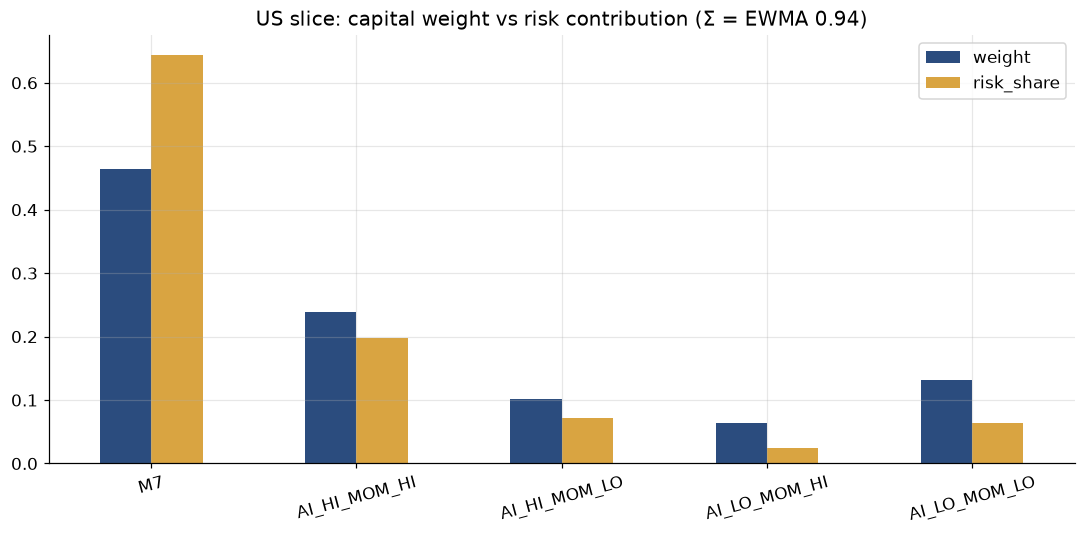

In [179]:
# ============ SNEAK PEEK: Task 1 close-out + Task 2 decomposition ============
from scipy.stats import norm

BASKETS  = ["M7", "AI_HI_MOM_HI", "AI_HI_MOM_LO", "AI_LO_MOM_HI", "AI_LO_MOM_LO"]
M7_FULL  = MAG7 + ["GOOG"]                      # both Alphabet classes belong in the anchor

w_all = pandas.to_numeric(equity_holdings.set_index("Ticker")["Weight (%)"],
                          errors="coerce").dropna()

# ---- 1. basket assignment at EVERY formation (recompute momentum per date) ----
assign_by_qe = {}
for qe, ld in sorted(loadings_by_qe.items()):
    p = members_returns.index.get_loc(qe)
    if p < 252:
        continue
    mom = tickers_data.iloc[p-21] / tickers_data.iloc[p-252] - 1
    tab = ld.join(mom.rename("momentum")).drop(index=[t for t in M7_FULL if t in ld.index],
                                               errors="ignore").dropna(subset=["ai_beta", "momentum"])
    hi_ai, hi_mom = tab["ai_beta"] >= tab["ai_beta"].median(), tab["momentum"] >= tab["momentum"].median()
    lab = np.select([hi_ai & hi_mom, hi_ai & ~hi_mom, ~hi_ai & hi_mom, ~hi_ai & ~hi_mom],
                    BASKETS[1:], default="UNASSIGNED")
    s = pandas.Series(lab, index=tab.index)
    m7 = pandas.Series("M7", index=[t for t in M7_FULL if t in members_returns.columns])
    assign_by_qe[qe] = pandas.concat([s, m7])
qes = sorted(assign_by_qe)

# ---- 2. basket daily return series, quarter block by quarter block ----
blocks = []
for i, qe in enumerate(qes):
    end   = qes[i+1] if i+1 < len(qes) else members_returns.index[-1]
    block = members_returns.loc[(members_returns.index > qe) & (members_returns.index <= end)]
    if block.empty: continue
    a, out = assign_by_qe[qe], {}
    for b in BASKETS:
        names = [t for t in a.index[a == b] if t in block.columns and t in w_all.index]
        X, w  = block[names], w_all[names]
        out[b] = (X.fillna(0) * w).sum(axis=1) / (X.notna() * w).sum(axis=1)
    blocks.append(pandas.DataFrame(out))
basket_rets = pandas.concat(blocks).sort_index()
print("basket returns:", basket_rets.index[0].date(), "→", basket_rets.index[-1].date(), basket_rets.shape)

# ---- 3. quick MAGS validation of the synthetic M7 ----
ok = pandas.concat([basket_rets["M7"], benchmark_returns["MAGS"]], axis=1).dropna()
print(f"M7 vs MAGS daily corr ({ok.index[0].date()} →): {ok.corr().iloc[0,1]:.4f}")

# ---- 4. current capital weights of the US slice, by basket ----
latest = assign_by_qe[qes[-1]]
cap    = pandas.Series({b: w_all[[t for t in latest.index[latest == b] if t in w_all.index]].sum()
                        for b in BASKETS})
w_vec  = (cap / cap.sum()).reindex(BASKETS)

# ---- 5. three Σ estimators on the basket series ----
R        = basket_rets.dropna()
sig_full = R.cov()
sig_1y   = R.tail(252).cov()
S = sig_1y.values.copy()
for r in R.values:                                   # RiskMetrics recursion, λ=0.94
    S = 0.94 * S + 0.06 * np.outer(r, r)
sig_ewma = pandas.DataFrame(S, index=R.columns, columns=R.columns)

# ---- 6. decomposition: MCR, component share, VaR/ES sensitivities (E1 formulas) ----
z, k_es = norm.ppf(0.01), norm.pdf(norm.ppf(0.01)) / 0.01

def decompose(sig, wv):
    w   = wv.reindex(sig.columns).values
    Sw  = sig.values @ w
    sp  = float(np.sqrt(w @ sig.values @ w))
    mcr = Sw / sp
    comp = w * mcr
    tab = pandas.DataFrame({"weight": w,
                            "ann_vol": np.sqrt(np.diag(sig.values) * 252),
                            "risk_share": comp / comp.sum(),
                            "dVaR_10D": z * mcr * np.sqrt(10),
                            "dES_10D": -k_es * mcr * np.sqrt(10)}, index=sig.columns)
    return tab, sp

results = {}
for name, sig in [("full-sample", sig_full), ("trailing 1y", sig_1y), ("EWMA 0.94", sig_ewma)]:
    tab, sp = decompose(sig, w_vec)
    results[name] = tab
    m7x     = tab.loc["M7", "risk_share"] / tab.loc["M7", "weight"]
    ai_gap  = tab.loc[["AI_HI_MOM_HI","AI_HI_MOM_LO"],"risk_share"].sum() \
            - tab.loc[["AI_LO_MOM_HI","AI_LO_MOM_LO"],"risk_share"].sum()
    mom_gap = tab.loc[["AI_HI_MOM_HI","AI_LO_MOM_HI"],"risk_share"].sum() \
            - tab.loc[["AI_HI_MOM_LO","AI_LO_MOM_LO"],"risk_share"].sum()
    print(f"\n--- Σ = {name}   (US-slice ann vol ≈ {sp*np.sqrt(252):.1%}) ---")
    print(tab.round(3))
    print(f"H1: M7 risk-share/weight = {m7x:.2f}x | H5: AI-split gap {ai_gap:+.1%} vs Mom-split gap {mom_gap:+.1%}")

results["EWMA 0.94"][["weight","risk_share"]].plot.bar(
    figsize=(10,5), rot=15, title="US slice: capital weight vs risk contribution (Σ = EWMA 0.94)")
plt.tight_layout()